In [47]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB

In [48]:
# Dataset
data = {
    'Outlook': ['Rainy', 'Rainy', 'Overcast', 'Sunny', 'Sunny', 'Sunny', 'Overcast', 
                'Rainy', 'Rainy', 'Sunny', 'Rainy', 'Overcast', 'Overcast', 'Sunny'],
    'Temp': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 
             'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 
                 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['FALSE', 'TRUE', 'FALSE', 'FALSE', 'FALSE', 'TRUE', 'TRUE', 
             'FALSE', 'FALSE', 'FALSE', 'TRUE', 'TRUE', 'FALSE', 'FALSE'],
    'Rain': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 
             'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}
df = pd.DataFrame(data)

In [93]:
# Separate LabelEncoders
le_outlook = LabelEncoder()
le_temp = LabelEncoder()
le_humidity = LabelEncoder()
le_wind = LabelEncoder()
le_rain = LabelEncoder()

# Encode
outlook_enc = le_outlook.fit_transform(df['Outlook'])
temp_enc = le_temp.fit_transform(df['Temp'])
humidity_enc = le_humidity.fit_transform(df['Humidity'])
wind_enc = le_wind.fit_transform(df['Wind'])
rain_enc = le_rain.fit_transform(df['Rain'])

print(outlook_enc)
print(temp_enc)
print(humidity_enc)
print(wind_enc)
print(rain_enc)


# Print mappings
print("\n" + "="*60)
print("Encoding Mappings:")
print(f"Outlook: {dict(zip(le_outlook.classes_, le_outlook.transform(le_outlook.classes_)))}")
print(f"Temp: {dict(zip(le_temp.classes_, le_temp.transform(le_temp.classes_)))}")
print(f"Humidity: {dict(zip(le_humidity.classes_, le_humidity.transform(le_humidity.classes_)))}")
print(f"Wind: {dict(zip(le_wind.classes_, le_wind.transform(le_wind.classes_)))}")
print(f"Rain: {dict(zip(le_rain.classes_, le_rain.transform(le_rain.classes_)))}")

[1 1 0 2 2 2 0 1 1 2 1 0 0 2]
[1 1 1 2 0 0 0 2 0 2 2 2 1 2]
[0 0 0 0 1 1 1 0 1 1 1 0 1 0]
[0 1 0 0 0 1 1 0 0 0 1 1 0 0]
[0 0 1 1 1 0 1 0 1 1 1 1 1 0]

Encoding Mappings:
Outlook: {'Overcast': 0, 'Rainy': 1, 'Sunny': 2}
Temp: {'Cool': 0, 'Hot': 1, 'Mild': 2}
Humidity: {'High': 0, 'Normal': 1}
Wind: {'FALSE': 0, 'TRUE': 1}
Rain: {'No': 0, 'Yes': 1}


In [50]:
# Prepare features
X = np.array(list(zip(outlook_enc, temp_enc, humidity_enc, wind_enc)))
y = np.array(rain_enc)

In [51]:
X

array([[1, 1, 0, 0],
       [1, 1, 0, 1],
       [0, 1, 0, 0],
       [2, 2, 0, 0],
       [2, 0, 1, 0],
       [2, 0, 1, 1],
       [0, 0, 1, 1],
       [1, 2, 0, 0],
       [1, 0, 1, 0],
       [2, 2, 1, 0],
       [1, 2, 1, 1],
       [0, 2, 0, 1],
       [0, 1, 1, 0],
       [2, 2, 0, 0]])

In [52]:
# Train model
model = GaussianNB()
model.fit(X, y)

GaussianNB()

In [53]:
# Predict: (Sunny, Hot, Normal, FALSE)
# Sunny=2, Hot=1, Normal=1, FALSE=0
today = [[2, 1, 1, 0]]
pred = model.predict(today)
prob = model.predict_proba(today)

print("\nPrediction for (Sunny, Hot, Normal, FALSE):")
print(f"Prediction: {'RAIN' if pred[0]==1 else 'NO RAIN'}")
print(f"Probability of Rain: {prob[0][1]:.2%}")
print(f"Probability of No Rain: {prob[0][0]:.2%}")


Prediction for (Sunny, Hot, Normal, FALSE):
Prediction: RAIN
Probability of Rain: 82.21%
Probability of No Rain: 17.79%


# NAIVE BAYES USING BAYES THEOREM - MANUAL CALCULATION

In [55]:
"""
NAIVE BAYES USING BAYES THEOREM - MANUAL CALCULATION
====================================================
Predicting Rain based on weather conditions
Test Case: Today = (Sunny, Hot, Normal, FALSE)
"""

import pandas as pd
import numpy as np
import math
from collections import defaultdict

In [56]:
# 1. CREATE DATASET
# ============================================================================

data = {
    'Outlook': ['Rainy', 'Rainy', 'Overcast', 'Sunny', 'Sunny', 'Sunny', 'Overcast', 
                'Rainy', 'Rainy', 'Sunny', 'Rainy', 'Overcast', 'Overcast', 'Sunny'],
    'Temp': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 
             'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 
                 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['FALSE', 'TRUE', 'FALSE', 'FALSE', 'FALSE', 'TRUE', 'TRUE', 
             'FALSE', 'FALSE', 'FALSE', 'TRUE', 'TRUE', 'FALSE', 'FALSE'],
    'Rain': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 
             'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}


In [57]:
df = pd.DataFrame(data)
print("="*80)
print("NAIVE BAYES USING BAYES THEOREM - MANUAL CALCULATION")
print("="*80)
print("\nDataset:")
print(df)
print(f"\nTotal Samples: {len(df)}")


NAIVE BAYES USING BAYES THEOREM - MANUAL CALCULATION

Dataset:
     Outlook  Temp Humidity   Wind Rain
0      Rainy   Hot     High  FALSE   No
1      Rainy   Hot     High   TRUE   No
2   Overcast   Hot     High  FALSE  Yes
3      Sunny  Mild     High  FALSE  Yes
4      Sunny  Cool   Normal  FALSE  Yes
5      Sunny  Cool   Normal   TRUE   No
6   Overcast  Cool   Normal   TRUE  Yes
7      Rainy  Mild     High  FALSE   No
8      Rainy  Cool   Normal  FALSE  Yes
9      Sunny  Mild   Normal  FALSE  Yes
10     Rainy  Mild   Normal   TRUE  Yes
11  Overcast  Mild     High   TRUE  Yes
12  Overcast   Hot   Normal  FALSE  Yes
13     Sunny  Mild     High  FALSE   No

Total Samples: 14


In [65]:
# ============================================================================
# 2. TODAY'S CONDITION
# ============================================================================

today = {'Outlook': 'Sunny', 'Temp': 'Hot', 'Humidity': 'Normal', 'Wind': 'FALSE'}
print("\nToday's Weather:")
print(f"  {today}")


Today's Weather:
  {'Outlook': 'Sunny', 'Temp': 'Hot', 'Humidity': 'Normal', 'Wind': 'FALSE'}


In [69]:
print("\n" + "="*60)
print("STEP 1: PRIOR PROBABILITIES")
print("="*60)

# Prior probabilities
total = len(df)
yes_count = len(df[df['Rain'] == 'Yes'])
no_count = len(df[df['Rain'] == 'No'])

p_yes = yes_count / total
p_no = no_count / total

print(f"P(Rain=Yes) = {yes_count}/{total} = {p_yes:.4f}")
print(f"P(Rain=No) = {no_count}/{total} = {p_no:.4f}")


STEP 1: PRIOR PROBABILITIES
P(Rain=Yes) = 9/14 = 0.6429
P(Rain=No) = 5/14 = 0.3571


In [ ]:
print("\n" + "="*60)
print("STEP 2: CONDITIONAL PROBABILITIES")
print("="*60)

# Helper function
def prob(feature, value, rain_status):
    filtered = df[df['Rain'] == rain_status]
    count = len(filtered[filtered[feature] == value])
    total = len(filtered)
    return count, total, count/total if total > 0 else 0


STEP 2: CONDITIONAL PROBABILITIES


In [71]:
# For Rain = Yes
print("\nFor Rain = Yes:")
sunny_yes, total_yes, p_sunny_yes = prob('Outlook', 'Sunny', 'Yes')
hot_yes, total_yes, p_hot_yes = prob('Temp', 'Hot', 'Yes')
normal_yes, total_yes, p_normal_yes = prob('Humidity', 'Normal', 'Yes')
false_yes, total_yes, p_false_yes = prob('Wind', 'FALSE', 'Yes')

print(f"  P(Sunny|Yes) = {sunny_yes}/{yes_count} = {p_sunny_yes:.4f}")
print(f"  P(Hot|Yes) = {hot_yes}/{yes_count} = {p_hot_yes:.4f}")
print(f"  P(Normal|Yes) = {normal_yes}/{yes_count} = {p_normal_yes:.4f}")
print(f"  P(FALSE|Yes) = {false_yes}/{yes_count} = {p_false_yes:.4f}")


For Rain = Yes:
  P(Sunny|Yes) = 3/9 = 0.3333
  P(Hot|Yes) = 2/9 = 0.2222
  P(Normal|Yes) = 6/9 = 0.6667
  P(FALSE|Yes) = 6/9 = 0.6667


In [72]:
# For Rain = No
print("\nFor Rain = No:")
sunny_no, total_no, p_sunny_no = prob('Outlook', 'Sunny', 'No')
hot_no, total_no, p_hot_no = prob('Temp', 'Hot', 'No')
normal_no, total_no, p_normal_no = prob('Humidity', 'Normal', 'No')
false_no, total_no, p_false_no = prob('Wind', 'FALSE', 'No')

print(f"  P(Sunny|No) = {sunny_no}/{no_count} = {p_sunny_no:.4f}")
print(f"  P(Hot|No) = {hot_no}/{no_count} = {p_hot_no:.4f}")
print(f"  P(Normal|No) = {normal_no}/{no_count} = {p_normal_no:.4f}")
print(f"  P(FALSE|No) = {false_no}/{no_count} = {p_false_no:.4f}")


For Rain = No:
  P(Sunny|No) = 2/5 = 0.4000
  P(Hot|No) = 2/5 = 0.4000
  P(Normal|No) = 1/5 = 0.2000
  P(FALSE|No) = 3/5 = 0.6000


In [73]:
print("\n" + "="*60)
print("STEP 3: BAYES THEOREM CALCULATION")
print("="*60)

# Joint probabilities (unnormalized posteriors)
joint_yes = p_yes * p_sunny_yes * p_hot_yes * p_normal_yes * p_false_yes
joint_no = p_no * p_sunny_no * p_hot_no * p_normal_no * p_false_no

print(f"\nP(Yes ∩ Features) = {p_yes:.4f} × {p_sunny_yes:.4f} × {p_hot_yes:.4f} × {p_normal_yes:.4f} × {p_false_yes:.4f}")
print(f"                   = {joint_yes:.6f}")

print(f"\nP(No ∩ Features) = {p_no:.4f} × {p_sunny_no:.4f} × {p_hot_no:.4f} × {p_normal_no:.4f} × {p_false_no:.4f}")
print(f"                  = {joint_no:.6f}")

# P(Features) = sum of joint probabilities
p_features = joint_yes + joint_no
print(f"\nP(Features) = {joint_yes:.6f} + {joint_no:.6f} = {p_features:.6f}")

# Posterior probabilities (normalized)
p_yes_given = joint_yes / p_features
p_no_given = joint_no / p_features

print(f"\nP(Rain=Yes | Today) = {joint_yes:.6f} / {p_features:.6f} = {p_yes_given:.4f} ({p_yes_given*100:.2f}%)")
print(f"P(Rain=No | Today) = {joint_no:.6f} / {p_features:.6f} = {p_no_given:.4f} ({p_no_given*100:.2f}%)")


STEP 3: BAYES THEOREM CALCULATION

P(Yes ∩ Features) = 0.6429 × 0.3333 × 0.2222 × 0.6667 × 0.6667
                   = 0.021164

P(No ∩ Features) = 0.3571 × 0.4000 × 0.4000 × 0.2000 × 0.6000
                  = 0.006857

P(Features) = 0.021164 + 0.006857 = 0.028021

P(Rain=Yes | Today) = 0.021164 / 0.028021 = 0.7553 (75.53%)
P(Rain=No | Today) = 0.006857 / 0.028021 = 0.2447 (24.47%)


In [ ]:
# ============================================================================
# 5. FINAL PREDICTION
# ============================================================================

print("\n" + "="*60)
print("STEP 4: FINAL PREDICTION")
print("="*60)

if p_yes_given > p_no_given:
    print("\nPREDICTION: It will RAIN today!")
    print(f"   Confidence: {p_yes_given*100:.2f}%")
else:
    print("\nPREDICTION: It will NOT rain today!")
    print(f"   Confidence: {p_no_given*100:.2f}%")


STEP 4: FINAL PREDICTION

PREDICTION: It will RAIN today!
   Confidence: 75.53%


In [75]:
# ============================================================================
# 6. SUMMARY TABLE
# ============================================================================

print("\n" + "="*60)
print("SUMMARY")
print("="*60)

summary = pd.DataFrame({
    'Class': ['Rain=Yes', 'Rain=No'],
    'Prior': [p_yes, p_no],
    'Likelihood': [p_sunny_yes*p_hot_yes*p_normal_yes*p_false_yes, 
                   p_sunny_no*p_hot_no*p_normal_no*p_false_no],
    'Joint': [joint_yes, joint_no],
    'Posterior': [p_yes_given, p_no_given]
})
print(summary.to_string(index=False))


SUMMARY
   Class    Prior  Likelihood    Joint  Posterior
Rain=Yes 0.642857    0.032922 0.021164   0.755287
 Rain=No 0.357143    0.019200 0.006857   0.244713


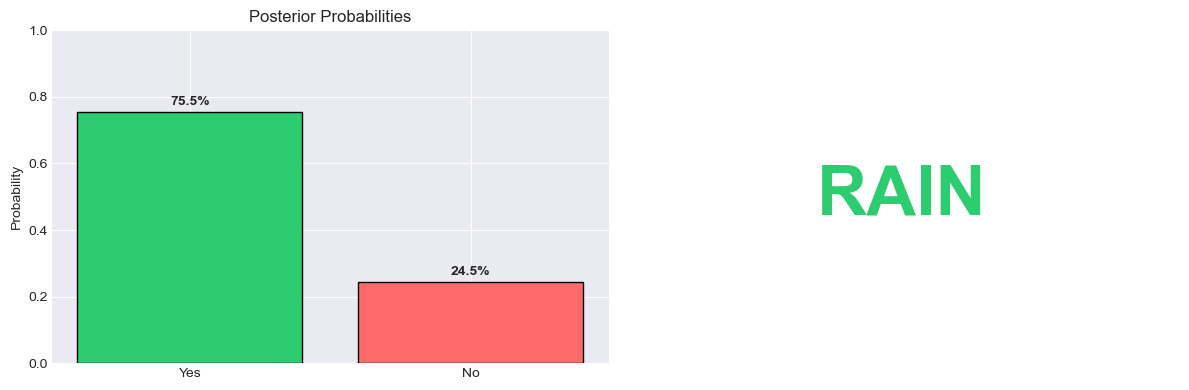


COMPLETED SUCCESSFULLY!


In [81]:
# ============================================================================
# 7. VISUALIZATION
# ============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
ax1.bar(['Yes', 'No'], [p_yes_given, p_no_given], 
        color=['#2ECC71', '#FF6B6B'], edgecolor='black')
ax1.set_title('Posterior Probabilities')
ax1.set_ylabel('Probability')
ax1.set_ylim(0, 1)
for i, v in enumerate([p_yes_given, p_no_given]):
    ax1.text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# Result display
ax2.axis('off')

result = 'RAIN' if p_yes_given > p_no_given else 'NO RAIN'
color = '#2ECC71' if p_yes_given > p_no_given else '#FF6B6B'
ax2.text(0.5, 0.5, f'{result}', fontsize=50, ha='center', va='center',
         fontweight='bold', color=color, transform=ax2.transAxes)

plt.tight_layout()
plt.savefig('bayes_simple.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("COMPLETED SUCCESSFULLY!")
print("="*60)